### Imports

In [11]:
#Required modules and setting variables
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.model_selection import train_test_split
import joblib

### Loading Data

In [12]:
#Load data and save in pandas DataFrame
datafolder="../astro/CALplots/"
eminstr=("-5.0")

datapath=datafolder+"fitspectra-HeP_fitsave%s.dat"%eminstr
data = pd.DataFrame()
with open(datapath, "rb") as file:
    foundfiles,globpardict,pflxs,pfs,x2s,x2dict,vx2s,vx2dict,rx2s,rx2dict,px2s,px2dict,hx2s,hx2dict,fx2s,fx2dict,qx2s,qx2dict,vfx2s,vfx2dict,likes,likedict,mlikes,mlikedict,tlikes,tlikedict,qlikes,qlikedict,tss,tsdict,faultfiles,faultpardict,corrfactlist = pickle.load(file)
    globpardict["Y1"]=rx2s
    globpardict["Y2"]=fx2s
    globpardict["Y3"]=px2s
    globpardict["Y4"]=hx2s
    data = pd.DataFrame.from_dict(globpardict)
print(data.shape)
print(data.head(3))

(5037, 21)
   sindex  nuccut  diffexp  lowindx  lowexp  lowdiffbreak  lowdiffbreaksoft  \
0  2.8382    27.0   0.5740      2.0  0.3126       12.3284            0.0535   
1  2.8382    32.0   0.5721      2.0  0.3132       12.3207            0.0538   
2  2.8370    32.0   0.5510      2.0  0.3065       12.2774            0.0546   

   diffnorm    DE    DR  ...  highexp  diffbreak  diffbreaksoft  lowbreak  \
0    1.2950  2.68  4.62  ...   0.0530   914.5000         0.3262    7.8100   
1    1.3023  2.67  4.66  ...   0.0563   926.6701         0.3238    7.8577   
2    1.3461  2.83  4.58  ...   0.0427   958.5050         0.3135    7.6944   

   lowsoft  spiralwidth         Y1          Y2         Y3         Y4  
0   0.2240          0.3  16.644259  265.111020  67.492702  71.153454  
1   0.2216          0.3  17.120809  257.755821  80.549417  69.237324  
2   0.2352          0.3  18.680217  327.889868  66.152806  72.369979  

[3 rows x 21 columns]


### Missing Data?

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5037 entries, 0 to 5036
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sindex            5037 non-null   float64
 1   nuccut            5037 non-null   float64
 2   diffexp           5037 non-null   float64
 3   lowindx           5037 non-null   float64
 4   lowexp            5037 non-null   float64
 5   lowdiffbreak      5037 non-null   float64
 6   lowdiffbreaksoft  5037 non-null   float64
 7   diffnorm          5037 non-null   float64
 8   DE                5037 non-null   float64
 9   DR                5037 non-null   float64
 10  alvel             5037 non-null   float64
 11  highexp           5037 non-null   float64
 12  diffbreak         5037 non-null   float64
 13  diffbreaksoft     5037 non-null   float64
 14  lowbreak          5037 non-null   float64
 15  lowsoft           5037 non-null   float64
 16  spiralwidth       5037 non-null   float64


In [14]:
data.isnull().any()

sindex              False
nuccut              False
diffexp             False
lowindx             False
lowexp              False
lowdiffbreak        False
lowdiffbreaksoft    False
diffnorm            False
DE                  False
DR                  False
alvel               False
highexp             False
diffbreak           False
diffbreaksoft       False
lowbreak            False
lowsoft             False
spiralwidth         False
Y1                  False
Y2                  False
Y3                  False
Y4                  False
dtype: bool

### Basic Visualizations

#### Correlation Matrix

Text(0.5, 1.0, 'Correlation Matrix')

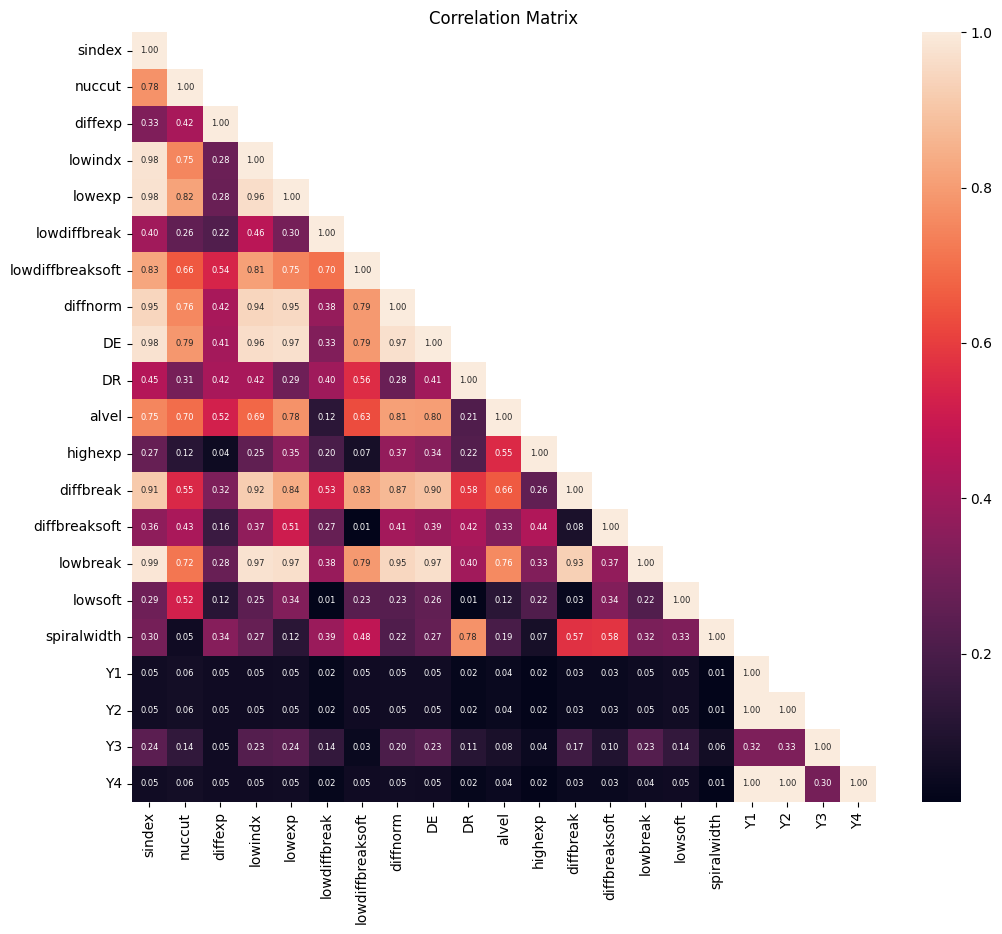

In [15]:
fig, ax = plt.subplots(figsize=(12,10))
cor_matrix = data.corr(numeric_only=True).abs()
upper_tri=cor_matrix.where(np.tril(np.ones(cor_matrix.shape), k=0).astype(bool))
ax=sns.heatmap(upper_tri, annot=True, annot_kws={"size":6}, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix")

        Above correlations show, we should only fit to two uncorrelated outputs! (e.g. Y1, Y3)

#### Histograms

array([[<Axes: title={'center': 'sindex'}>,
        <Axes: title={'center': 'nuccut'}>,
        <Axes: title={'center': 'diffexp'}>,
        <Axes: title={'center': 'lowindx'}>,
        <Axes: title={'center': 'lowexp'}>],
       [<Axes: title={'center': 'lowdiffbreak'}>,
        <Axes: title={'center': 'lowdiffbreaksoft'}>,
        <Axes: title={'center': 'diffnorm'}>,
        <Axes: title={'center': 'DE'}>, <Axes: title={'center': 'DR'}>],
       [<Axes: title={'center': 'alvel'}>,
        <Axes: title={'center': 'highexp'}>,
        <Axes: title={'center': 'diffbreak'}>,
        <Axes: title={'center': 'diffbreaksoft'}>,
        <Axes: title={'center': 'lowbreak'}>],
       [<Axes: title={'center': 'lowsoft'}>,
        <Axes: title={'center': 'spiralwidth'}>,
        <Axes: title={'center': 'Y1'}>, <Axes: title={'center': 'Y2'}>,
        <Axes: title={'center': 'Y3'}>],
       [<Axes: title={'center': 'Y4'}>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

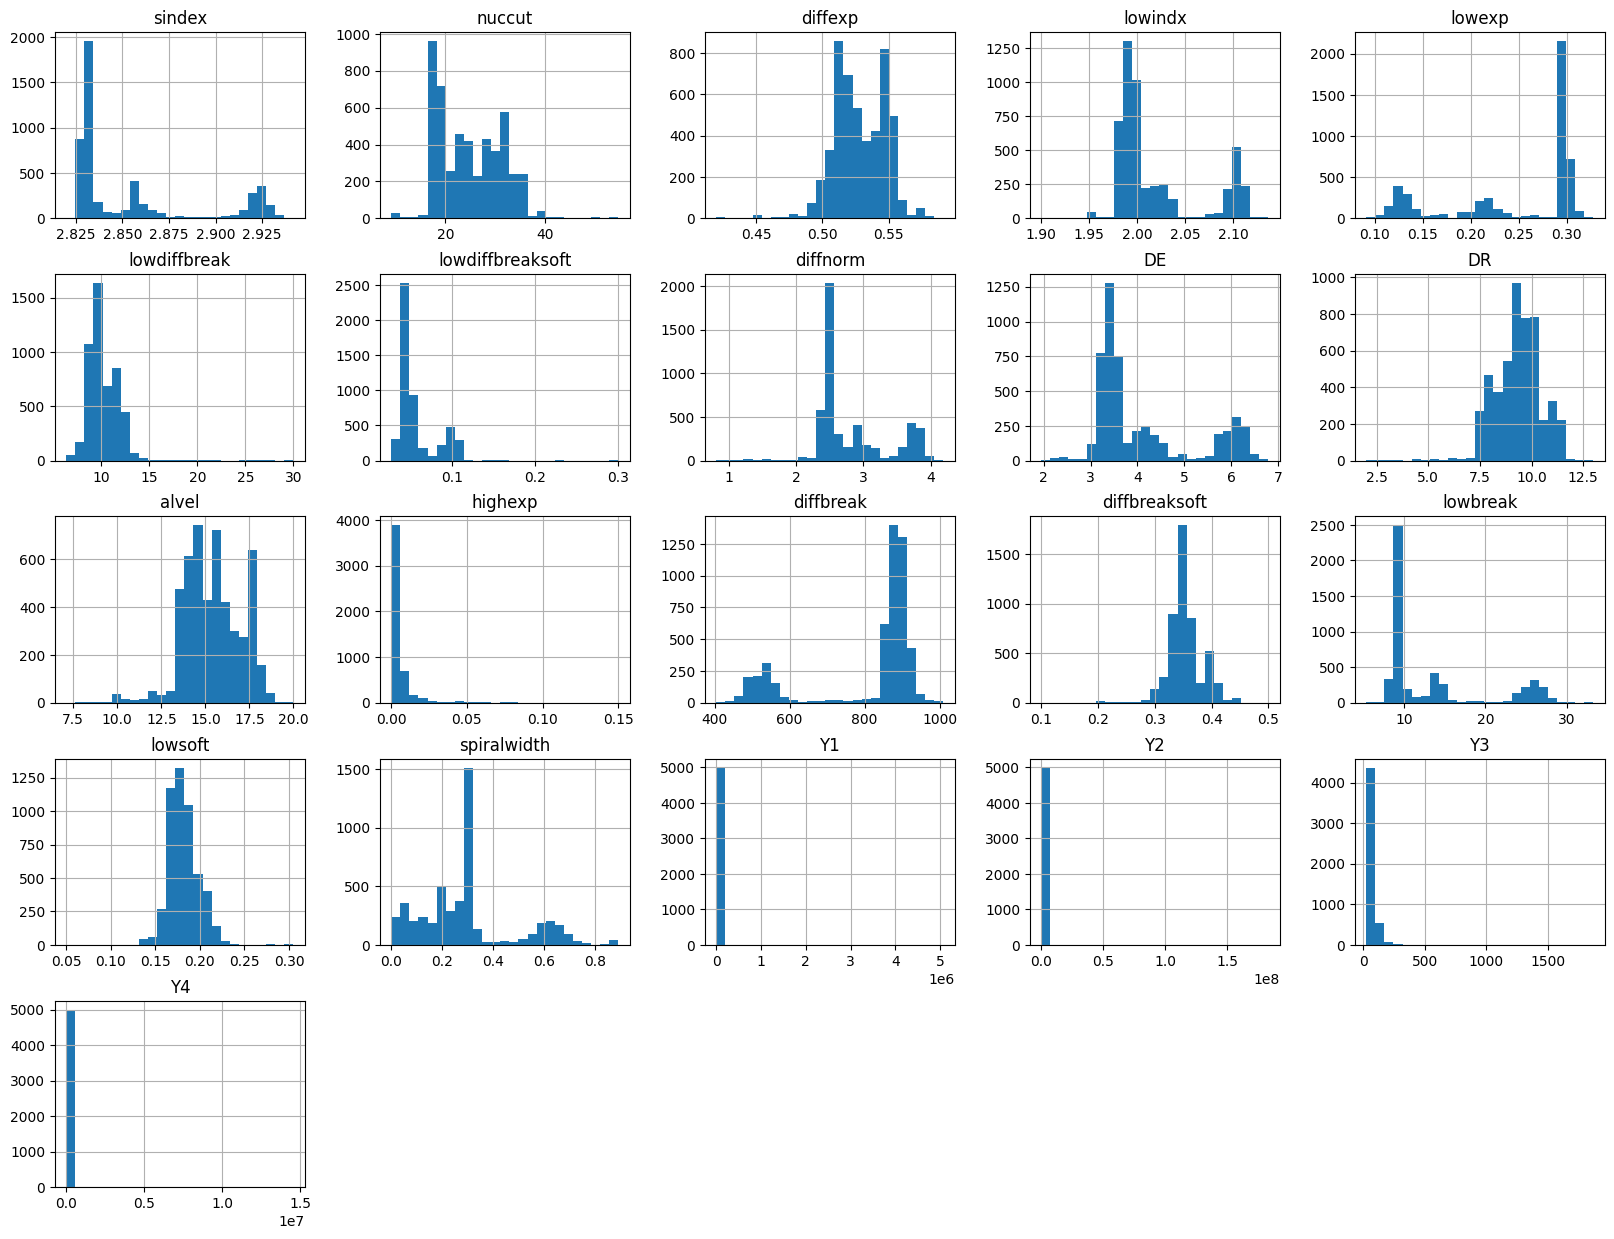

In [16]:
data.hist(bins=25, figsize=(20,15))

# sns.pairplot(data[0:1])

#### Outliers

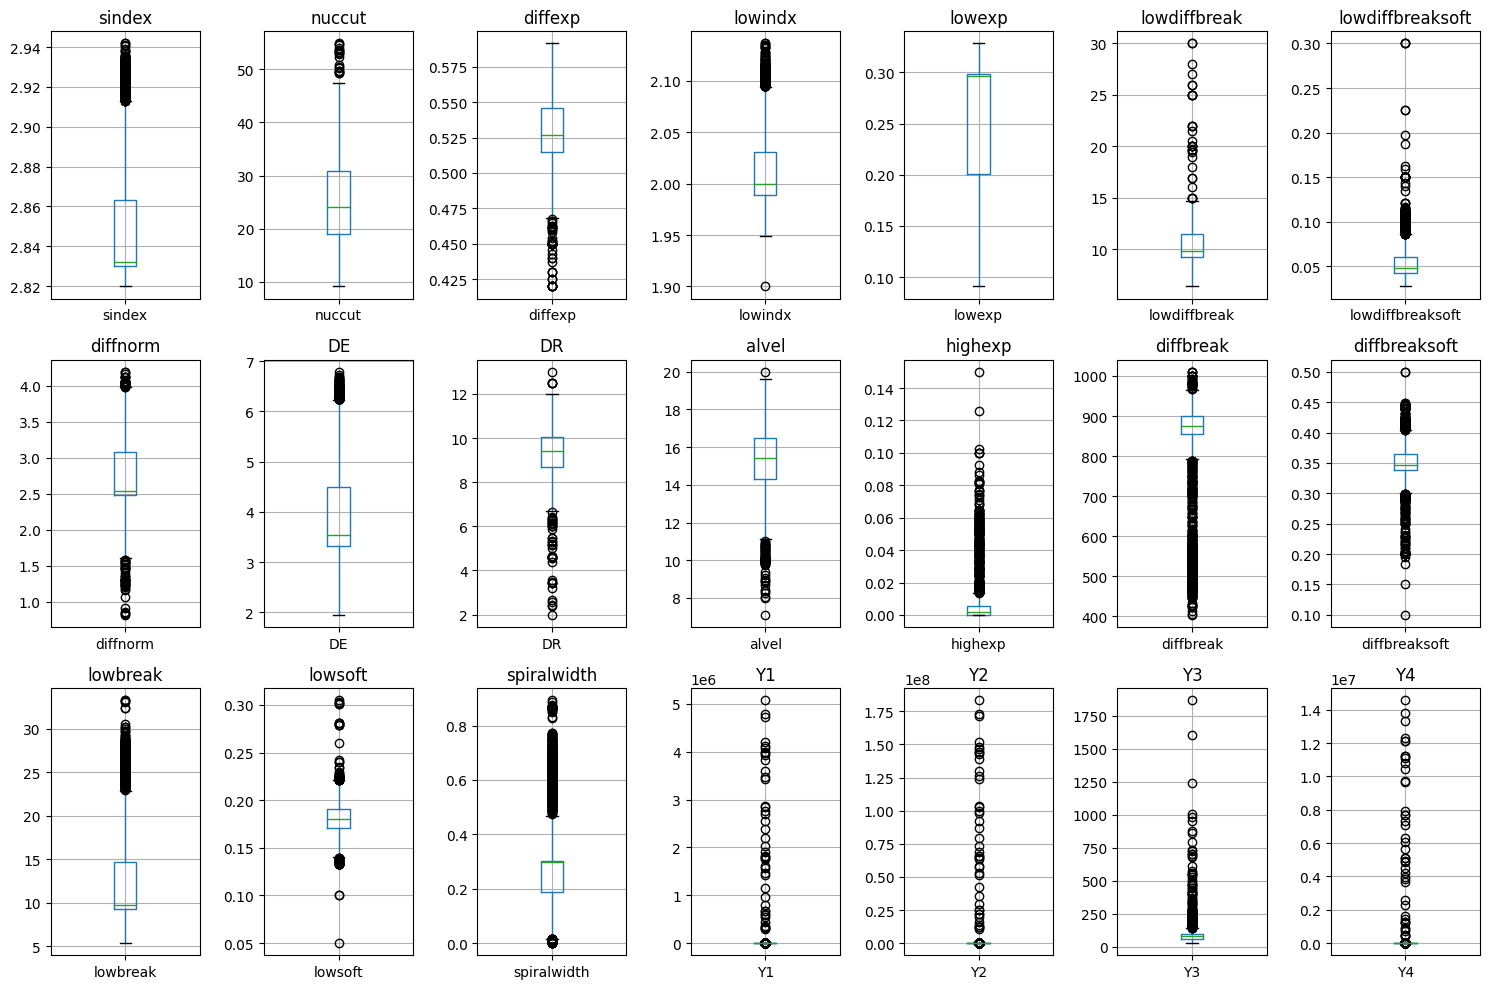

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=len(data.columns)//3 + (len(data.columns) % 3 > 0), figsize=(15, 10))

# Plot boxplots for each column
for i, column in enumerate(data.columns):
    row = i // (len(data.columns) // 3)
    col = i % (len(data.columns) // 3)
    data.boxplot(column, ax=axes[row, col])
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'Y1'}>, <Axes: title={'center': 'Y2'}>],
       [<Axes: title={'center': 'Y3'}>, <Axes: title={'center': 'Y4'}>]],
      dtype=object)

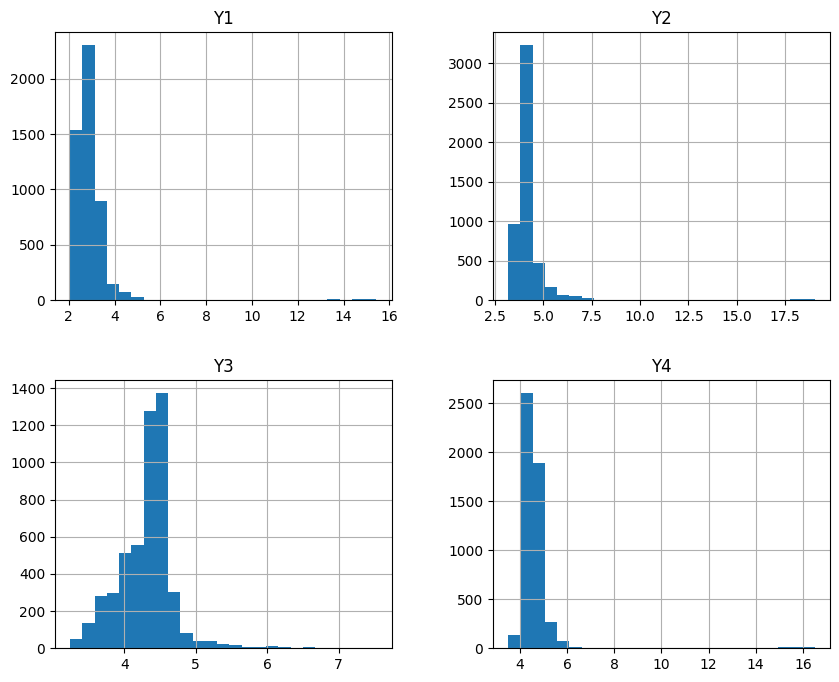

In [18]:
# # Standardize + Log:
# data_log=np.log(data[["Y1", "Y2", "Y3", "Y4"]])
# scaler_test=StandardScaler()
# scaler_test.fit(data_log)
# data_stand = pd.DataFrame(scaler_test.transform(data_log))                                           
# data_stand.hist(bins=25, figsize=(10,8))

# Just log
data_log=np.log(data[["Y1", "Y2", "Y3", "Y4"]])
data_log = pd.DataFrame(data_log)                                           
data_log.hist(bins=25, figsize=(10,8))

There are a few outliers (4%) with orders of magnitude larger Chi2 which could mess with the NN loss functions. I removed those outliers for training in the one of the following datasets.

### Saving Processed Data:

#### Raw Data

In [19]:
# Save X and y as Dataframes:    
ycolumns = ["Y1", "Y2", "Y3", "Y4"]
y = data[ycolumns]
X = data.drop(columns=ycolumns)

datadict_unsplit = {
    "X": X,
    "y": y
}
with open('Data/Raw/unsplit.pkl', 'wb') as file:
    pickle.dump(datadict_unsplit, file)
    
    
# Train-Val-Test-Split and save as Dataframes:
X_train, X_alt, y_train, y_alt = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_alt, y_alt, test_size=0.5, random_state=69)

datadict_split = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}
with open('Data/Raw/split.pkl', 'wb') as file:
    pickle.dump(datadict_split, file)

#### Transformed Data (Logscaling, Standardize, ...)

In [20]:
#First create a train-test-split, all conclusions drawn can only come from the training set (prevent data leakage!)
columns = data.columns
ycolumns = ["Y1", "Y2", "Y3", "Y4"]
Xcolumns = [x for x in columns if x not in ycolumns]
y = data[ycolumns]
X = data.drop(columns=ycolumns)
X_train, X_alt, y_train, y_alt = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize x-data, log-trafo and standardize on y-data, apply transformations won also on testing data (without refitting as this would cause differently transformed sets)
normalizer = MinMaxScaler()
log_trafo = FunctionTransformer(np.log1p)
scaler=StandardScaler()

X_train = normalizer.fit_transform(X_train)
y_train = log_trafo.transform(y_train)
y_train = scaler.fit_transform(y_train)

X_alt=normalizer.transform(X_alt)
y_alt=log_trafo.transform(y_alt)
y_alt=scaler.transform(y_alt)

X_train, y_train, X_alt, y_alt = pd.DataFrame(X_train, columns=Xcolumns), pd.DataFrame(y_train, columns=ycolumns), pd.DataFrame(X_alt, columns=Xcolumns), pd.DataFrame(y_alt, columns=ycolumns)
X_val, X_test, y_val, y_test = train_test_split(X_alt, y_alt, test_size=0.5, random_state=69)
datadict_split = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}
with open('Data/Transformed/split.pkl', 'wb') as file:
    pickle.dump(datadict_split, file)


#Save as dataset - Dataset objects allow easy training of NNs:
class TensorDataset(Dataset):
    def __init__(self, X, y):
        # Initialize data, convert from pd df to tensor
        # Here I am already expecting pretransformed data as given above
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    def __len__(self):
        return len(self.X)   
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

datadict_dataset = {
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
}
with open('Data/Transformed/dataset.pkl', 'wb') as file:
    pickle.dump(datadict_dataset, file)
    
print("Stds:\n", y_test.std())
print("Mean Stds:\n", y_test.std().mean())
print("Mean L2 Stds:\n", np.sqrt(np.square(y_test.std()).mean()))


Stds:
 Y1    0.936992
Y2    0.937671
Y3    1.027618
Y4    0.926339
dtype: float64
Mean Stds:
 0.9571549419517231
Mean L2 Stds:
 0.9580296351817498


#### Transformation + Outlier Removal

In [22]:
#First create a train-test-split, all conclusions drawn can only come from the training set (prevent data leakage!)
columns = data.columns
ycolumns = ["Y1", "Y2", "Y3", "Y4"]
y = data[ycolumns]
X = data.drop(columns=ycolumns)
X_train, X_alt, y_train, y_alt = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize x-data, log-trafo and standardize on y-data, apply transformations won also on testing data (without refitting as this would cause differently transformed sets)
normalizer = MinMaxScaler()
log_trafo = FunctionTransformer(np.log1p)
scaler=StandardScaler()

X_train = normalizer.fit_transform(X_train)
y_train = log_trafo.transform(y_train)
y_train = scaler.fit_transform(y_train)

X_alt=normalizer.transform(X_alt)
y_alt=log_trafo.transform(y_alt)
y_alt=scaler.transform(y_alt)

joblib.dump(normalizer, "Data/Transformed_OutlierAdjusted/xNormalizer.pkl")
joblib.dump(scaler, "Data/Transformed_OutlierAdjusted/yScaler.pkl")

# Dropping outliers in Y data (with Z-score >= 3) as they randomly cause high losses
data_train = pd.DataFrame(np.concatenate([X_train, y_train], axis=1), columns=columns)
data_alt = pd.DataFrame(np.concatenate([X_alt, y_alt], axis=1), columns=columns)

Z_crit = 3.0
for column in ycolumns:
    column_mean = np.nanmean(data_train[column])
    column_std = np.nanstd(data_train[column])
    data_train[column+"Z"] = np.abs((data_train[column]-column_mean)/column_std)
    data_alt[column+"Z"] = np.abs((data_alt[column]-column_mean)/column_std)
for column in ycolumns:
    data_train = data_train[data_train[column+"Z"]<Z_crit]
    data_train = data_train.drop(column+"Z", axis=1)
    data_alt = data_alt[data_alt[column+"Z"]<Z_crit]
    data_alt = data_alt.drop(column+"Z", axis=1)

dropped=len(data)-len(data_alt)-len(data_train)
print(f"Dropped data: {dropped}/{len(data)} = {100*dropped/len(data):.2f}%")


#Create validation and testing set (validation set for hyperparameter adjustment, testing set for last test with fully trained NN, otherwise data leakage during hyperparameter optimization)
y_train = data_train[ycolumns]
X_train = data_train.drop(columns=ycolumns)
y_alt = data_alt[ycolumns]
X_alt = data_alt.drop(columns=ycolumns)

print("Stds:\n", y_train.std())
print("Mean Stds:\n", y_train.std().mean())
print("Mean L2 Stds:\n", np.sqrt(np.square(y_train.std()).mean()))

X_val, X_test, y_val, y_test = train_test_split(X_alt, y_alt, test_size=0.5, random_state=69)

#save processed data as dataframes:
datadict_split = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}
with open('Data/Transformed_OutlierAdjusted/split.pkl', 'wb') as file:
    pickle.dump(datadict_split, file)

#save processed datasets to pickle file:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)
dataset_dict = {
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
}
with open('Data/Transformed_OutlierAdjusted/dataset.pkl', 'wb') as file:
    pickle.dump(dataset_dict, file)
    

Dropped data: 77/5037 = 1.53%
Stds:
 Y1    0.382842
Y2    0.393101
Y3    0.855315
Y4    0.321282
dtype: float64
Mean Stds:
 0.48813513529948355
Mean L2 Stds:
 0.5328889494983466


array([[<Axes: title={'center': 'sindex'}>,
        <Axes: title={'center': 'nuccut'}>,
        <Axes: title={'center': 'diffexp'}>,
        <Axes: title={'center': 'lowindx'}>,
        <Axes: title={'center': 'lowexp'}>],
       [<Axes: title={'center': 'lowdiffbreak'}>,
        <Axes: title={'center': 'lowdiffbreaksoft'}>,
        <Axes: title={'center': 'diffnorm'}>,
        <Axes: title={'center': 'DE'}>, <Axes: title={'center': 'DR'}>],
       [<Axes: title={'center': 'alvel'}>,
        <Axes: title={'center': 'highexp'}>,
        <Axes: title={'center': 'diffbreak'}>,
        <Axes: title={'center': 'diffbreaksoft'}>,
        <Axes: title={'center': 'lowbreak'}>],
       [<Axes: title={'center': 'lowsoft'}>,
        <Axes: title={'center': 'spiralwidth'}>,
        <Axes: title={'center': 'Y1'}>, <Axes: title={'center': 'Y2'}>,
        <Axes: title={'center': 'Y3'}>],
       [<Axes: title={'center': 'Y4'}>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

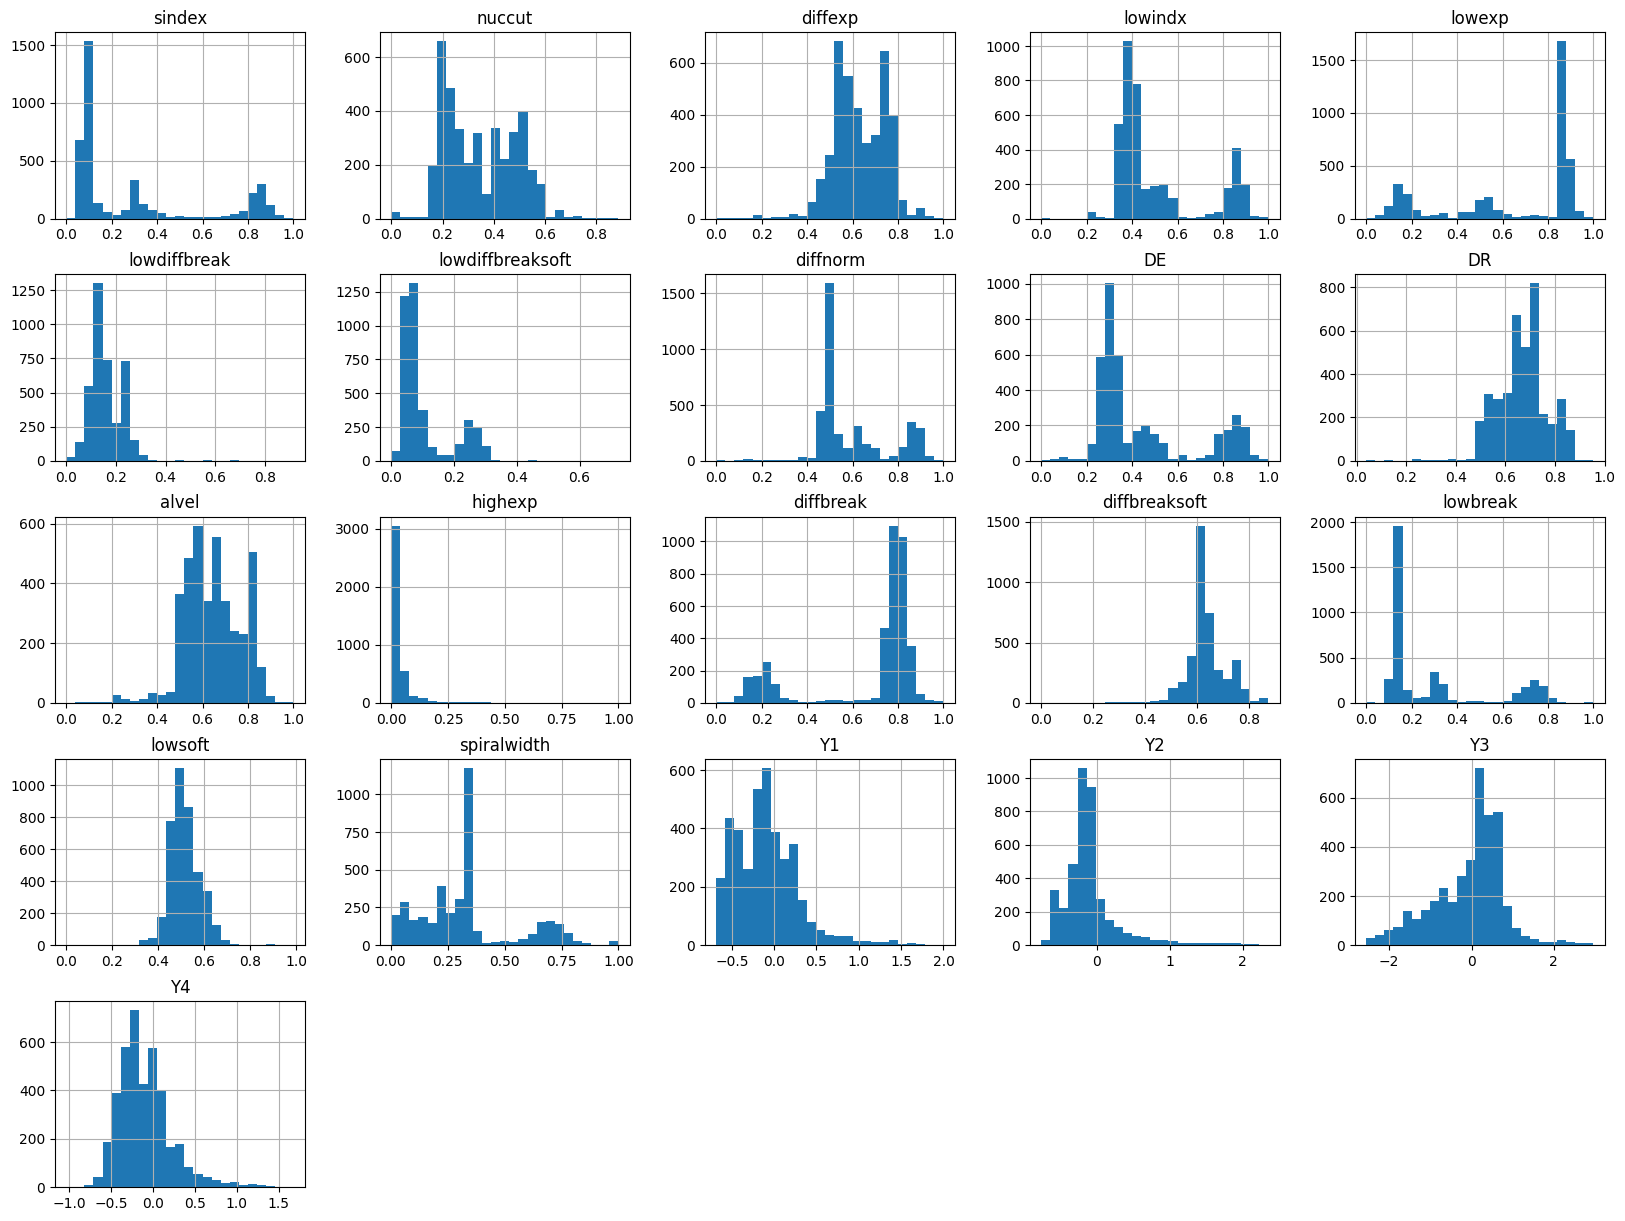

In [12]:
data_train.hist(bins=25, figsize=(20,15))

Text(0.5, 1.0, 'Correlation Matrix')

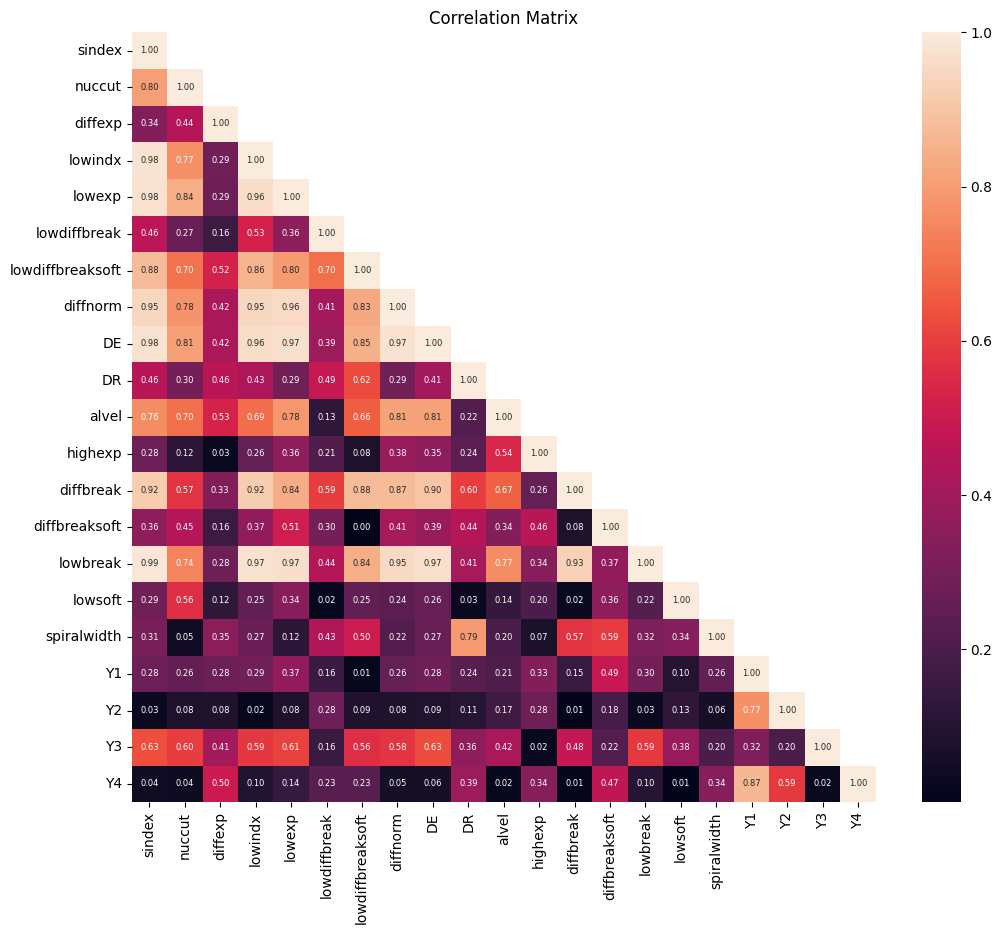

In [13]:
fig, ax = plt.subplots(figsize=(12,10))
cor_matrix = pd.concat([X_train, y_train], axis=1).corr(numeric_only=True).abs()
upper_tri=cor_matrix.where(np.tril(np.ones(cor_matrix.shape), k=0).astype(bool))
ax=sns.heatmap(upper_tri, annot=True, annot_kws={"size":6}, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix")

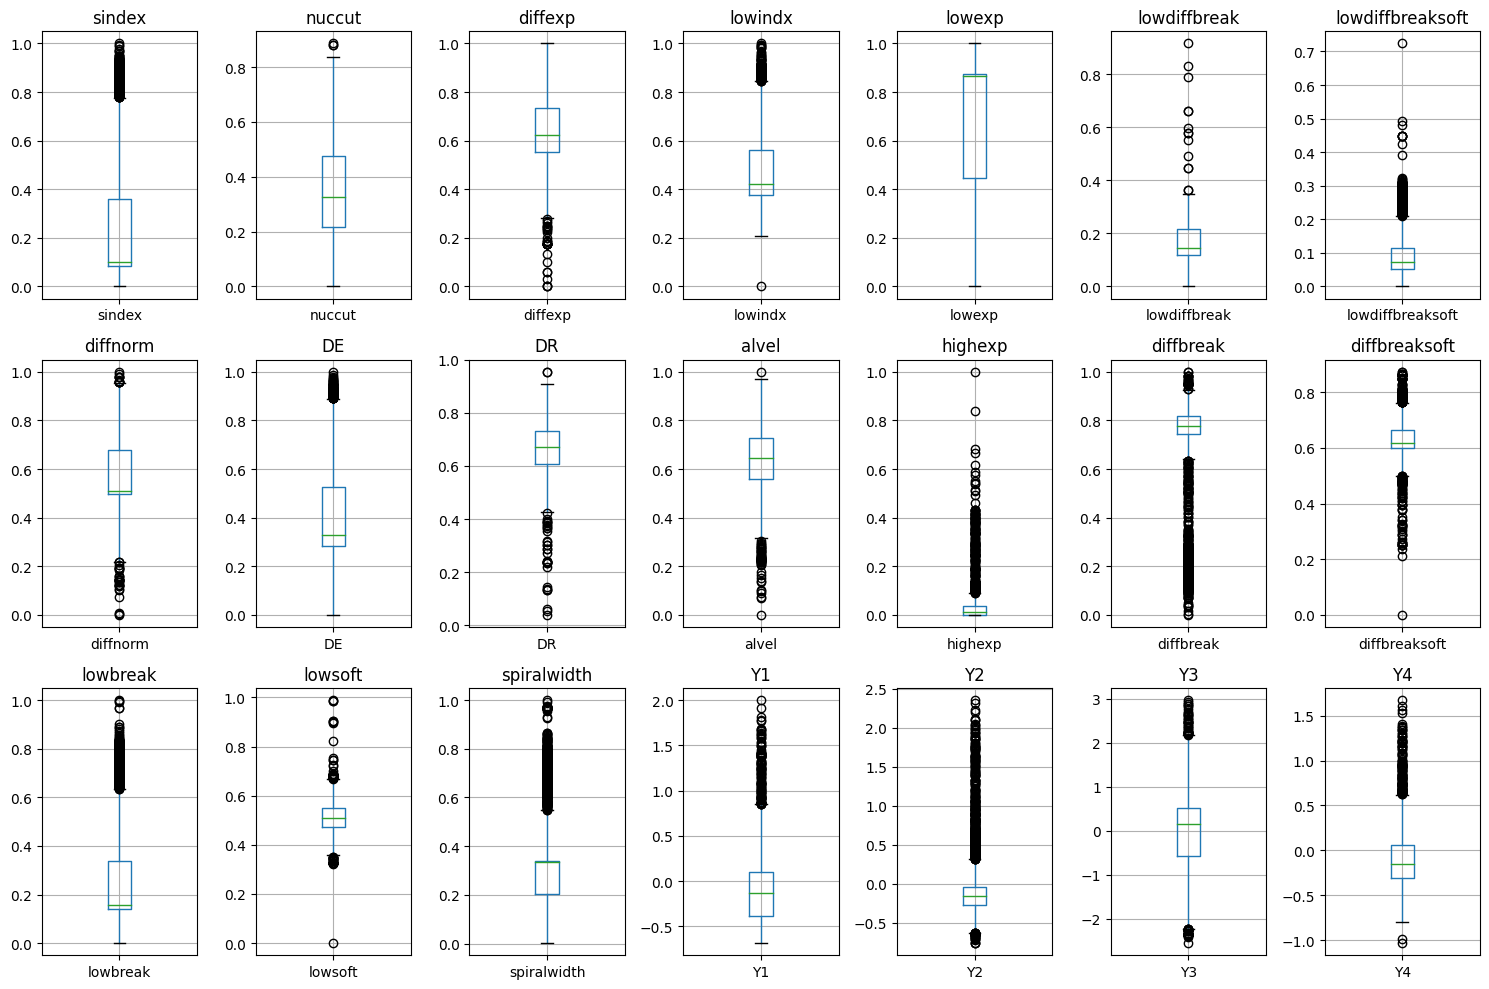

In [14]:
fig, axes = plt.subplots(nrows=3, ncols=len(data_train.columns)//3 + (len(data_train.columns) % 3 > 0), figsize=(15, 10))

# Plot boxplots for each column
for i, column in enumerate(data_train.columns):
    row = i // (len(data_train.columns) // 3)
    col = i % (len(data_train.columns) // 3)
    data_train.boxplot(column, ax=axes[row, col])
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'Y1'}>, <Axes: title={'center': 'Y2'}>],
       [<Axes: title={'center': 'Y3'}>, <Axes: title={'center': 'Y4'}>]],
      dtype=object)

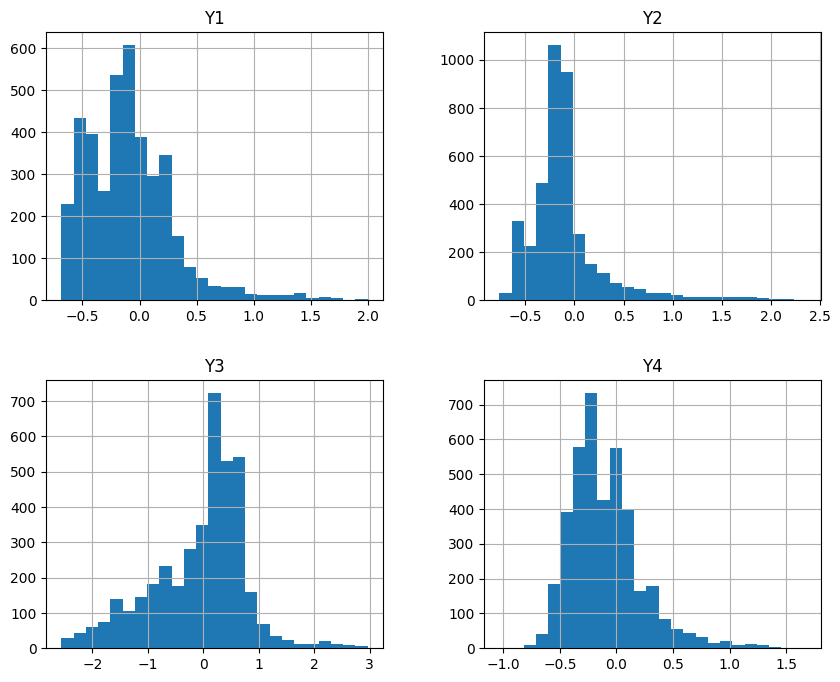

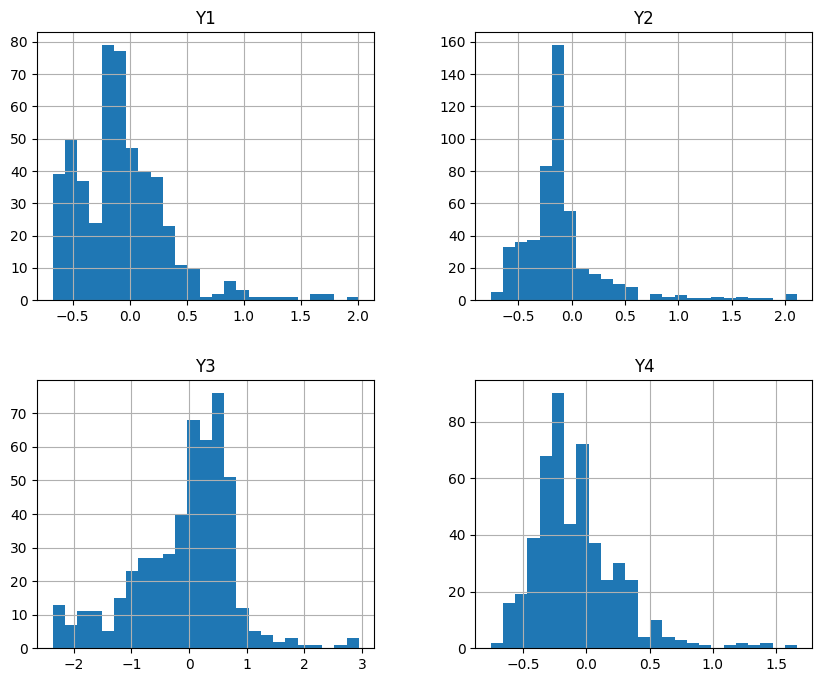

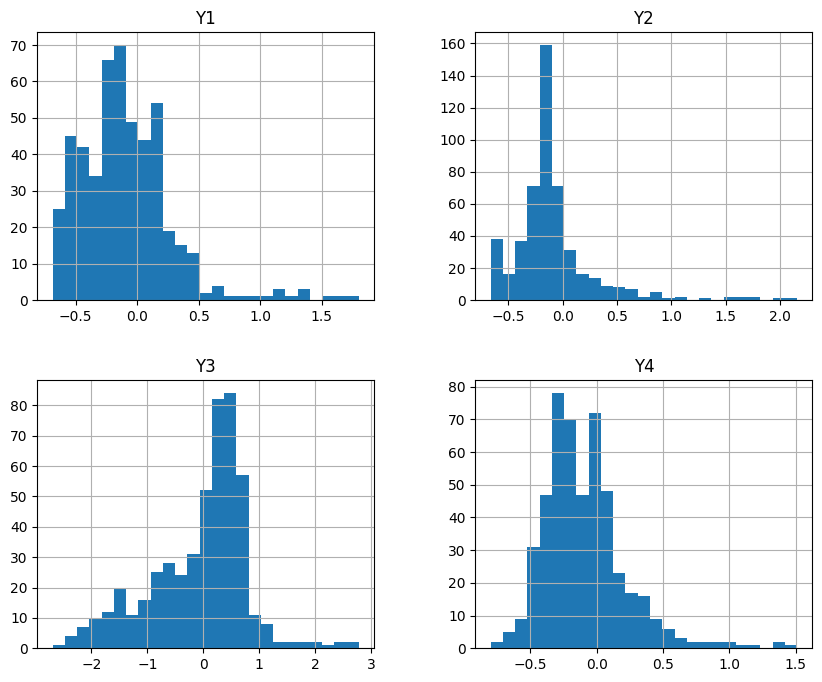

In [15]:
y_train.hist(bins=25, figsize=(10,8))
y_val.hist(bins=25, figsize=(10,8))
y_test.hist(bins=25, figsize=(10,8))
